### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [65]:
data = pd.read_csv('data/coupons.csv')

In [66]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

We begin by looking for Duplicates, and look for high level description of the data using .info(), and finding Null values.

In [18]:
data.duplicated().sum()

np.int64(74)

In [54]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

In [19]:
data.isnull().sum()

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

In [27]:
data.car[data['car'].notna()]

1237                      Scooter and motorcycle
1238                      Scooter and motorcycle
1239                      Scooter and motorcycle
1240                      Scooter and motorcycle
1241                      Scooter and motorcycle
                          ...                   
8293    Car that is too old to install Onstar :D
8294    Car that is too old to install Onstar :D
8295    Car that is too old to install Onstar :D
8296    Car that is too old to install Onstar :D
8297    Car that is too old to install Onstar :D
Name: car, Length: 108, dtype: object

In [31]:
data['car'].value_counts()

car
Scooter and motorcycle                      22
Mazda5                                      22
do not drive                                22
crossover                                   21
Car that is too old to install Onstar :D    21
Name: count, dtype: int64

In [37]:
data['CoffeeHouse'].value_counts()

CoffeeHouse
less1    3385
1~3      3225
never    2962
4~8      1784
gt8      1111
Name: count, dtype: int64

3. Decide what to do about your missing data -- drop, replace, other...

## Data cleansing section
Before manipulating the data we need to ensure we keep the original source intact, and create a new dataframe with the cleaned up data.  We will create a new data frame called "df".

In [40]:
data[data['CarryAway'].isnull()]

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8644,Home,Alone,Sunny,80,6PM,Bar,2h,Female,26,Married partner,...,less1,NaN,less1,less1,1,0,0,1,0,1
8645,Work,Alone,Rainy,55,7AM,Restaurant(<20),2h,Female,26,Married partner,...,less1,NaN,less1,less1,1,1,1,0,1,0
8646,Work,Alone,Snowy,30,7AM,Restaurant(<20),2h,Female,26,Married partner,...,less1,NaN,less1,less1,1,1,1,0,1,0
8647,Work,Alone,Snowy,30,7AM,Restaurant(20-50),1d,Female,26,Married partner,...,less1,NaN,less1,less1,1,1,1,0,1,0


In [41]:
# We drop the 'car' column once we realized that the content is incomplete and so irrelevant to our study
# We also create a new data frame df, and do not manipulate the original data source
df = data.drop(columns=['car'])

In [46]:
# Verify that the 'car' column has actually been dropped
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  Bar                   12577 non-null  object
 15  CoffeeHouse           12467 non-null

In [48]:
# We verify that the new data frame only has few rows with NaN values, so we can decide if we drop them or not.
df.isnull().sum()

destination               0
passanger                 0
weather                   0
temperature               0
time                      0
coupon                    0
expiration                0
gender                    0
age                       0
maritalStatus             0
has_children              0
education                 0
occupation                0
income                    0
Bar                     107
CoffeeHouse             217
CarryAway               151
RestaurantLessThan20    130
Restaurant20To50        189
toCoupon_GEQ5min          0
toCoupon_GEQ15min         0
toCoupon_GEQ25min         0
direction_same            0
direction_opp             0
Y                         0
dtype: int64

We do not have enough information about the gathering process to decide if we should replace the missing data points in the 'Bar', CoffeeHouse', 'CarryAway', 'RestaurantLessThan20' and 'Restaurant20To50' columns with other values, and filling in one of the values could inject personal biases.  We consider this reasonable since the Null values are a small percentage of the data.  Less than 5%.

In [51]:
# Drop the rows with Null values.  
df = df.dropna()

In [53]:
# we verify that the rows with Null values have been dropped
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12079 entries, 22 to 12683
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12079 non-null  object
 1   passanger             12079 non-null  object
 2   weather               12079 non-null  object
 3   temperature           12079 non-null  int64 
 4   time                  12079 non-null  object
 5   coupon                12079 non-null  object
 6   expiration            12079 non-null  object
 7   gender                12079 non-null  object
 8   age                   12079 non-null  object
 9   maritalStatus         12079 non-null  object
 10  has_children          12079 non-null  int64 
 11  education             12079 non-null  object
 12  occupation            12079 non-null  object
 13  income                12079 non-null  object
 14  Bar                   12079 non-null  object
 15  CoffeeHouse           12079 non-null  ob

In [59]:
# We check the unique values in each column to understand the data better and to see if there are any anomalies.
# Also, to check if there are any categorical variables that we need to encode before we can use them in our models.
unique_vals = {col: pd.unique(df[col]).tolist() for col in df.columns}

for col, vals in unique_vals.items():
    print(f"--- {col} ({len(vals)} unique) ---")
    print(vals)
    print()

--- destination (3 unique) ---
['No Urgent Place', 'Home', 'Work']

--- passanger (4 unique) ---
['Alone', 'Friend(s)', 'Kid(s)', 'Partner']

--- weather (3 unique) ---
['Sunny', 'Rainy', 'Snowy']

--- temperature (3 unique) ---
[55, 80, 30]

--- time (5 unique) ---
['2PM', '10AM', '6PM', '7AM', '10PM']

--- coupon (5 unique) ---
['Restaurant(<20)', 'Coffee House', 'Bar', 'Carry out & Take away', 'Restaurant(20-50)']

--- expiration (2 unique) ---
['1d', '2h']

--- gender (2 unique) ---
['Male', 'Female']

--- age (8 unique) ---
['21', '46', '26', '31', '41', '50plus', '36', 'below21']

--- maritalStatus (5 unique) ---
['Single', 'Married partner', 'Unmarried partner', 'Divorced', 'Widowed']

--- has_children (2 unique) ---
[0, 1]

--- education (6 unique) ---
['Bachelors degree', 'Some college - no degree', 'Associates degree', 'High School Graduate', 'Graduate degree (Masters or Doctorate)', 'Some High School']

--- occupation (25 unique) ---
['Architecture & Engineering', 'Student',

## Column unification
After examining the unique values of all columns I noticed that some columns should be unified, in order to reduce the number of columns, and simplify the possible analysis.
This happens with the three "time to coupon" columns which should be one column, and also with the "direction" columns which could be "merged" into one.

In [61]:
# Create TimetoCoupon column by taking the highest value that has a 1
def get_time_to_coupon(row):
    if row['toCoupon_GEQ25min'] == 1:
        return 25
    elif row['toCoupon_GEQ15min'] == 1:
        return 15
    elif row['toCoupon_GEQ5min'] == 1:
        return 5
    else:
        return 0

df['TimetoCoupon'] = df.apply(get_time_to_coupon, axis=1)

In [62]:
# Verify that the new column has been created and has the expected values
df.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y,TimetoCoupon
22,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Male,21,Single,...,4~8,4~8,less1,1,0,0,0,1,1,5
23,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Male,21,Single,...,4~8,4~8,less1,1,0,0,0,1,0,5
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,4~8,4~8,less1,1,0,0,0,1,1,5
25,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Male,21,Single,...,4~8,4~8,less1,1,1,0,0,1,0,15
26,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Male,21,Single,...,4~8,4~8,less1,1,0,0,0,1,0,5


In [64]:
# Drop the original columns
df.drop(columns=['toCoupon_GEQ5min', 'toCoupon_GEQ15min', 'toCoupon_GEQ25min'], inplace=True)


In [67]:
df.head()


,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,income,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,direction_same,direction_opp,Y,TimetoCoupon
22,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Male,21,Single,...,$62500 - $74999,never,less1,4~8,4~8,less1,0,1,1,5
23,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Male,21,Single,...,$62500 - $74999,never,less1,4~8,4~8,less1,0,1,0,5
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,$62500 - $74999,never,less1,4~8,4~8,less1,0,1,1,5
25,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Male,21,Single,...,$62500 - $74999,never,less1,4~8,4~8,less1,0,1,0,15
26,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Male,21,Single,...,$62500 - $74999,never,less1,4~8,4~8,less1,0,1,0,5


In [74]:
# We check if the direction columns are mutually exlusive, and the result says they are
# So we can use only on the columns to represent the direction of the trip, and we can drop the other one
df[df['direction_same'] == 1].groupby('direction_opp')['destination'].count()

direction_opp
0    2599
Name: destination, dtype: int64

In [75]:
# We drop the direction_opp column
df.drop(columns=['direction_opp'], inplace=True)


In [78]:
# We rename the Y column to accepted_coupon for better readability
df.rename(columns={'Y': 'accepted_coupon'}, inplace=True)

## Analysis
After finalizing the cleansing and clarification, we begin the analysis

4. What proportion of the total observations chose to accept the coupon?



In [84]:
# We count the number of accepted coupons and divide by the total number of rows to get the proportion of accepted coupons
count_accepted = (df['accepted_coupon']==1).sum()
totalrows = len(df)
proportion_accepted = count_accepted / totalrows
print(f"Proportion of accepted coupons: {proportion_accepted:.2%}")

Proportion of accepted coupons: 56.93%


5. Use a bar plot to visualize the `coupon` column.

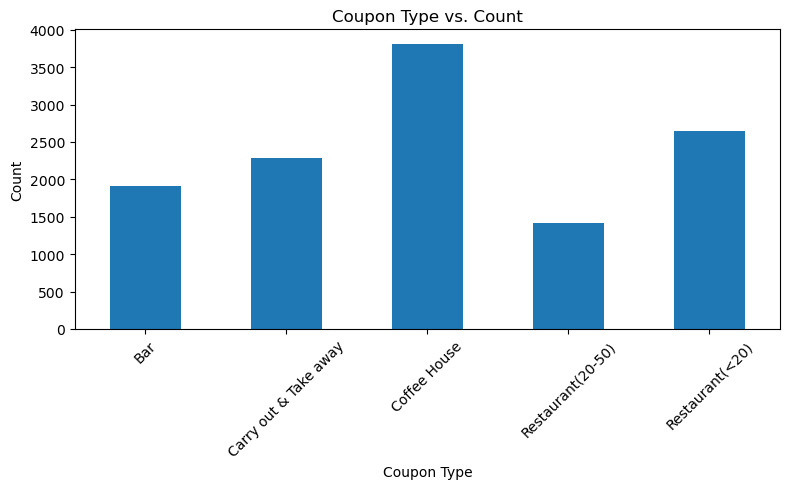

In [97]:
# We count the number of each coupon type and plot a bar chart to visualize the distribution of coupon types
df['coupon'].value_counts().sort_index().plot(kind='bar', figsize=(8, 5))
plt.title('Coupon Type vs. Count')
plt.xlabel('Coupon Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

We notice the Coffee House coupon is the most offered.  However we stil do not know if it is the most widely accepted.  We continue the analysis.

6. Use a histogram to visualize the temperature column.

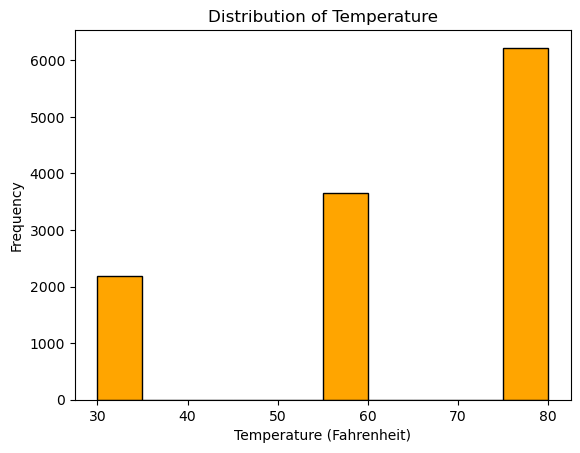

In [105]:
# We plot a histogram to visualize the distribution of temperature
plt.hist(df['temperature'], edgecolor='black', color='orange')
plt.title('Distribution of Temperature')
plt.xlabel('Temperature (Fahrenheit)')
plt.ylabel('Frequency')
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [107]:
# Select only the rows with the 'Bar' coupon type and create a new data frame df_bar
df_bar = df[df['coupon'] == 'Bar'].copy()
df_bar.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,occupation,income,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,direction_same,accepted_coupon,TimetoCoupon
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,Architecture & Engineering,$62500 - $74999,never,less1,4~8,4~8,less1,0,1,5
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,Architecture & Engineering,$62500 - $74999,never,less1,4~8,4~8,less1,1,1,5
39,Work,Alone,Sunny,55,7AM,Bar,1d,Male,21,Single,...,Architecture & Engineering,$62500 - $74999,never,less1,4~8,4~8,less1,0,1,25
46,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,46,Single,...,Student,$12500 - $24999,never,4~8,1~3,1~3,never,0,0,5
57,Home,Alone,Sunny,55,6PM,Bar,1d,Male,46,Single,...,Student,$12500 - $24999,never,4~8,1~3,1~3,never,1,0,5


2. What proportion of bar coupons were accepted?


In [189]:
# We count the number of Bar accepted coupons and divide by the total number of rows to get the proportion of accepted coupons
count_accepted_bar = (df_bar['accepted_coupon']==1).sum()
totalrows_bar= len(df_bar)
proportion_accepted_bar = count_accepted_bar / totalrows_bar
print(f"Proportion of Bar accepted coupons: {proportion_accepted_bar:.2%}")

Proportion of Bar accepted coupons: 41.19%


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


1720
Acceptance rate for those who went to a bar 3 or fewer times': 37.27%
Acceptance rate for those who went to a bar more than 3 times': 76.17%


Text(0, 0.5, 'Acceptance Rate')

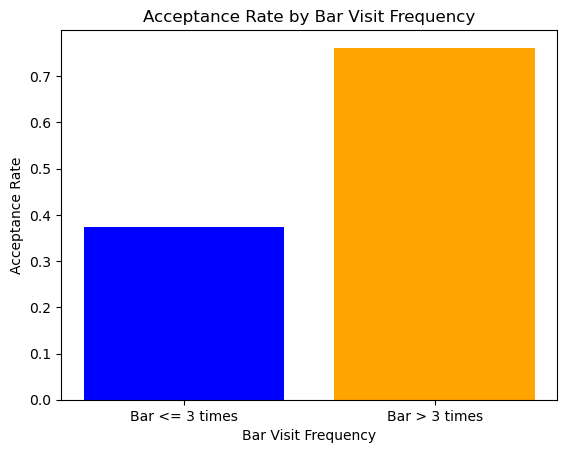

In [217]:
count_bar_less_than_3_accepted = df_bar[df_bar['accepted_coupon'] == 1]['Bar'].isin(['never', 'less1', '1~3']).sum()
#print(count_bar_less_than_3)
count_bar_less_than_3_total = df_bar['Bar'].isin(['never', 'less1', '1~3']).sum()
print(count_bar_less_than_3_total)
acceptance_rate_bar_less_than_3 = count_bar_less_than_3_accepted / count_bar_less_than_3_total
print(f"Acceptance rate for those who went to a bar 3 or fewer times': {acceptance_rate_bar_less_than_3:.2%}")

count_bar_other_accepted = (df_bar[df_bar['accepted_coupon'] == 1]['Bar'].isin(['never', 'less1', '1~3']) == False).sum()
count_bar_other_total = (df_bar['Bar'].isin(['never', 'less1', '1~3']) == False).sum()
acceptance_rate_bar_other = count_bar_other_accepted / count_bar_other_total
print(f"Acceptance rate for those who went to a bar more than 3 times': {acceptance_rate_bar_other:.2%}")
plt.bar(['Bar <= 3 times', 'Bar > 3 times'], [acceptance_rate_bar_less_than_3, acceptance_rate_bar_other], color=['blue', 'orange'])
plt.title('Acceptance Rate by Bar Visit Frequency')
plt.xlabel('Bar Visit Frequency')
plt.ylabel('Acceptance Rate')       



4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


Acceptance rate for drivers over 25 who go to a bar more than once a month: 68.98%
Acceptance rate for other drivers: 33.77%


C:\Users\paulb\AppData\Local\Temp\ipykernel_30032\4182922519.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=['Over 25 & Bar > 1/month', 'Other Drivers'], y=[acceptance_rate_group1, acceptance_rate_group2], palette='viridis')


Text(0, 0.5, 'Acceptance Rate (%)')

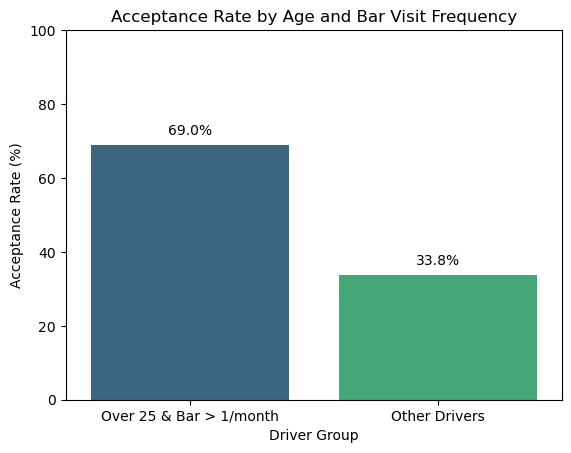

In [212]:
 
# We create lists of the numbers in the age column over age 25
list_over_25= ['26','31','36','41','46','50plus']
# We create a list of values of drivers who go to a bar more than once a month
list_more_than_one_bar = ['1~3', '4~8', 'gt8']

group1 = df_bar[df_bar['age'].isin(list_over_25) & df_bar['Bar'].isin(list_more_than_one_bar)]
group2 = df_bar.drop(group1.index)

acceptance_rate_group1 = group1['accepted_coupon'].mean() * 100
acceptance_rate_group2 = group2['accepted_coupon'].mean() * 100
print(f"Acceptance rate for drivers over 25 who go to a bar more than once a month: {round(acceptance_rate_group1, 2)}%")
print(f"Acceptance rate for other drivers: {round(acceptance_rate_group2, 2)}%")   

ax = sns.barplot(x=['Over 25 & Bar > 1/month', 'Other Drivers'], y=[acceptance_rate_group1, acceptance_rate_group2], palette='viridis')
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=5)
ax.bar_label(ax.containers[1], fmt='%.1f%%', padding=5)
ax.set_ylim(0, 100)
plt.title('Acceptance Rate by Age and Bar Visit Frequency') 
plt.xlabel('Driver Group')
plt.ylabel('Acceptance Rate (%)')   



With an acceptance rate of 69% the acceptance for drivers who go to a bar more than once a month and over the age of 25 is  significanly higher than that of other drivers with acceeptance of 34%.

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


Acceptance rate for drivers who go to a bar more than once a month, are not alone, and do not work in farming/fishing/forestry: 70.94%
Acceptance rate for other drivers: 29.79%


C:\Users\paulb\AppData\Local\Temp\ipykernel_30032\2717675490.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax =sns.barplot(x=['Bar > 1/month & Not Alone & Not Farming/Fishing/Forestry', 'Other Drivers'], y=[acceptance_rate_group1, acceptance_rate_group2], palette='magma')


([0, 1],
 [Text(0, 0, 'Bar > 1/month & Not Alone & Not Farming/Fishing/Forestry'),
  Text(1, 0, 'Other Drivers')])

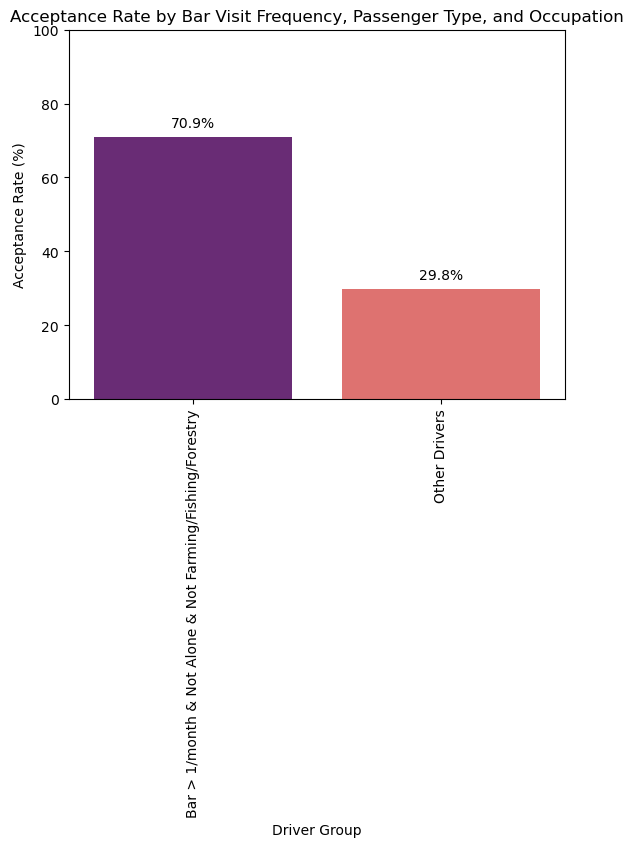

In [211]:
# create lists to easily filter the data for the next analysis
num_bar_visits_select = ['1~3', '4~8', 'gt8']
non_kid_passengers = ['Alone', 'Friend(s)', 'Partner']
occupation_different_from = ['Farming Fishing & Forestry']

group1 = df_bar[df_bar['Bar'].isin(num_bar_visits_select) & df_bar['passanger'].isin(non_kid_passengers) & (df_bar['occupation'].isin(occupation_different_from) == False)]
group2 = df_bar.drop(group1.index)

acceptance_rate_group1 = group1['accepted_coupon'].mean() * 100
acceptance_rate_group2 = group2['accepted_coupon'].mean() * 100
print(f"Acceptance rate for drivers who go to a bar more than once a month, are not alone, and do not work in farming/fishing/forestry: {round(acceptance_rate_group1, 2)}%")
print(f"Acceptance rate for other drivers: {round(acceptance_rate_group2, 2)}%")

ax =sns.barplot(x=['Bar > 1/month & Not Alone & Not Farming/Fishing/Forestry', 'Other Drivers'], y=[acceptance_rate_group1, acceptance_rate_group2], palette='magma')
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=5)
ax.bar_label(ax.containers[1], fmt='%.1f%%', padding=5)
ax.set_ylim(0, 100)
plt.title('Acceptance Rate by Bar Visit Frequency, Passenger Type, and Occupation')
plt.xlabel('Driver Group')
plt.ylabel('Acceptance Rate (%)')
plt.xticks(rotation=90)
    



6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



(746, 22) (1167, 22)
Acceptance rate for Target Group: 58.71%
Acceptance rate for other drivers: 29.99%


C:\Users\paulb\AppData\Local\Temp\ipykernel_30032\489709652.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=['Target Group', 'Other Drivers'], y=[acceptance_rate_group1, acceptance_rate_group2], palette='coolwarm')


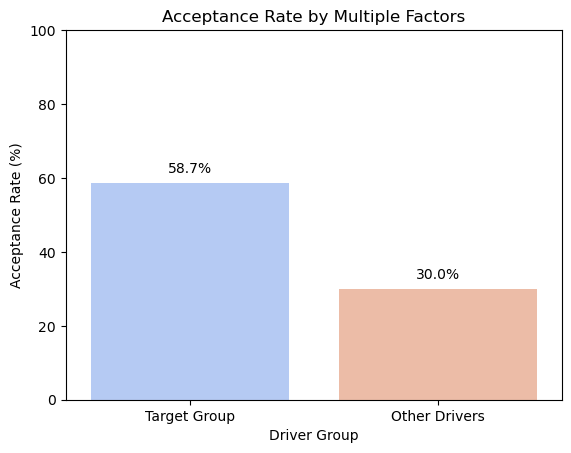

In [210]:
# create lists to easily filter the data for the next analysis
num_bar_visits_select = ['1~3', '4~8', 'gt8']
non_kid_passengers = ['Alone', 'Friend(s)', 'Partner']
widowed = ['Widowed']
age_under_30 = ['below21', '21', '26']
go_to_cheap_restaurants_4_or_more = ['4~8', 'gt8']
income_less_50K = ['Less than $12500', '$12500 - $24999', '$25000 - $37499', '$37500 - $49999']

group1 = df_bar[(df_bar['Bar'].isin(num_bar_visits_select) & df_bar['passanger'].isin(non_kid_passengers) & ~df_bar['maritalStatus'].isin(widowed)) | (df_bar['Bar'].isin(num_bar_visits_select) & df_bar['age'].isin(age_under_30)) | (df_bar['RestaurantLessThan20'].isin(go_to_cheap_restaurants_4_or_more) & df_bar['income'].isin(income_less_50K))]
group2 = df_bar.drop(group1.index)

print(group1.shape, group2.shape)

acceptance_rate_group1 = group1['accepted_coupon'].mean() * 100
acceptance_rate_group2 = group2['accepted_coupon'].mean() * 100 
print(f"Acceptance rate for Target Group: {round(acceptance_rate_group1, 2)}%")
print(f"Acceptance rate for other drivers: {round(acceptance_rate_group2, 2)}%")
ax = sns.barplot(x=['Target Group', 'Other Drivers'], y=[acceptance_rate_group1, acceptance_rate_group2], palette='coolwarm')
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=5)
ax.bar_label(ax.containers[1], fmt='%.1f%%', padding=5)
ax.set_ylim(0, 100)
plt.title('Acceptance Rate by Multiple Factors')
plt.xlabel('Driver Group')
plt.ylabel('Acceptance Rate (%)')
plt.show()



7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

Based on these observations we can conclude that there is a strong correlation between the frequency of going to a bar and the acceptance rate of the Bar coupon. Drivers who go to a bar more than once a month have a significantly higher acceptance rate compared to those who go less frequently. Additionally, drivers over 25 who go to a bar more than once a month also have a higher acceptance rate compared to other drivers. Furthermore, drivers who go to a bar more than once a month, are not alone, and do not work in farming/fishing/forestry also have a higher acceptance rate compared to other drivers. Finally, when considering multiple factors such as bar visit frequency, passenger type, marital status, age, restaurant visit frequency, and income, we can identify a target group that has a significantly higher acceptance rate compared to other drivers.

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

I begin by analyzing the acceptance rate of the Coffee House coupon.

In [176]:
df_coffee = df[df['coupon'] == 'Coffee House'].copy()
df_coffee.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,occupation,income,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,direction_same,accepted_coupon,TimetoCoupon
23,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Male,21,Single,...,Architecture & Engineering,$62500 - $74999,never,less1,4~8,4~8,less1,0,0,5
26,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Male,21,Single,...,Architecture & Engineering,$62500 - $74999,never,less1,4~8,4~8,less1,0,0,5
27,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Male,21,Single,...,Architecture & Engineering,$62500 - $74999,never,less1,4~8,4~8,less1,0,0,15
28,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Male,21,Single,...,Architecture & Engineering,$62500 - $74999,never,less1,4~8,4~8,less1,0,0,15
30,No Urgent Place,Friend(s),Sunny,80,6PM,Coffee House,2h,Male,21,Single,...,Architecture & Engineering,$62500 - $74999,never,less1,4~8,4~8,less1,0,0,5


In [177]:
acceptance_rate_coffee = df_coffee['accepted_coupon'].mean() * 100
print(f"Acceptance rate for Coffee House coupon: {acceptance_rate_coffee:.2f}%")


Acceptance rate for Coffee House coupon: 49.63%


After doing this, I realize that it would be better to begin with more Global analysis, trying to analyze acceptance rate for all coupon types.

Acceptance rate for each coupon type:
                  coupon  accepted_coupon
0                    Bar        41.191845
1  Carry out & Take away        73.771930
2           Coffee House        49.633124
3      Restaurant(20-50)        44.601270
4        Restaurant(<20)        70.900867


C:\Users\paulb\AppData\Local\Temp\ipykernel_30032\1854160217.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='coupon', y='accepted_coupon', data=acceptance_rate_all, palette='Set2')


([0, 1, 2, 3, 4],
 [Text(0, 0, 'Bar'),
  Text(1, 0, 'Carry out & Take away'),
  Text(2, 0, 'Coffee House'),
  Text(3, 0, 'Restaurant(20-50)'),
  Text(4, 0, 'Restaurant(<20)')])

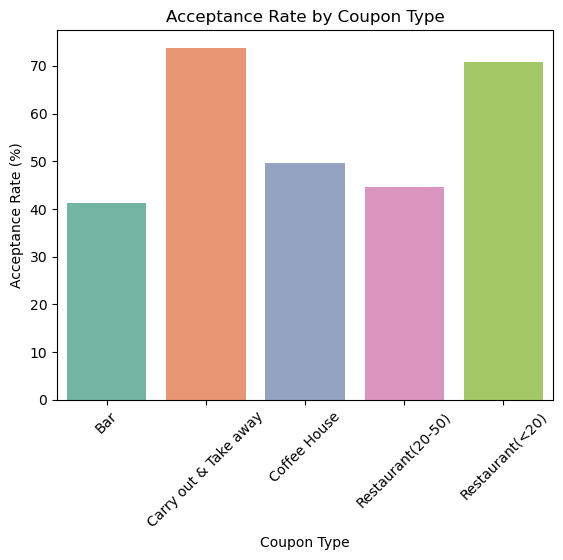

In [184]:
acceptance_rate_all = df.groupby('coupon')['accepted_coupon'].mean() * 100
print("Acceptance rate for each coupon type:")  
acceptance_rate_all = acceptance_rate_all.reset_index()
print(acceptance_rate_all)

sns.barplot(x='coupon', y='accepted_coupon', data=acceptance_rate_all, palette='Set2')
plt.title('Acceptance Rate by Coupon Type') 
plt.xlabel('Coupon Type')
plt.ylabel('Acceptance Rate (%)')   
plt.xticks(rotation=45)


However,this high level view does not provide specific insight into example of campaigns that we could run.  So we research for ways in which we could get more insight of many categories all at once.

TimetoCoupon
5     61.509434
15    56.042721
25    43.411928
Name: accepted_coupon, dtype: float64


C:\Users\paulb\AppData\Local\Temp\ipykernel_30032\856370343.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=acceptance_rate_TimetoCoupon.index, y=acceptance_rate_TimetoCoupon.values, palette='Set1')


Text(0.5, 0, 'Time to Coupon (minutes)')

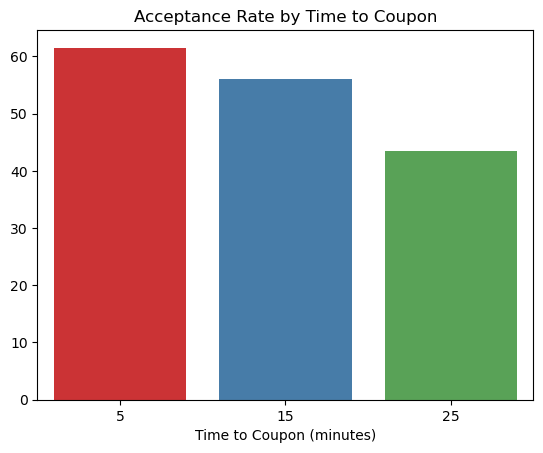

In [186]:
acceptance_rate_TimetoCoupon = df.groupby('TimetoCoupon')['accepted_coupon'].mean() * 100

print(acceptance_rate_TimetoCoupon)
sns.barplot(x=acceptance_rate_TimetoCoupon.index, y=acceptance_rate_TimetoCoupon.values, palette='Set1')
plt.title('Acceptance Rate by Time to Coupon')  
plt.xlabel('Time to Coupon (minutes)')

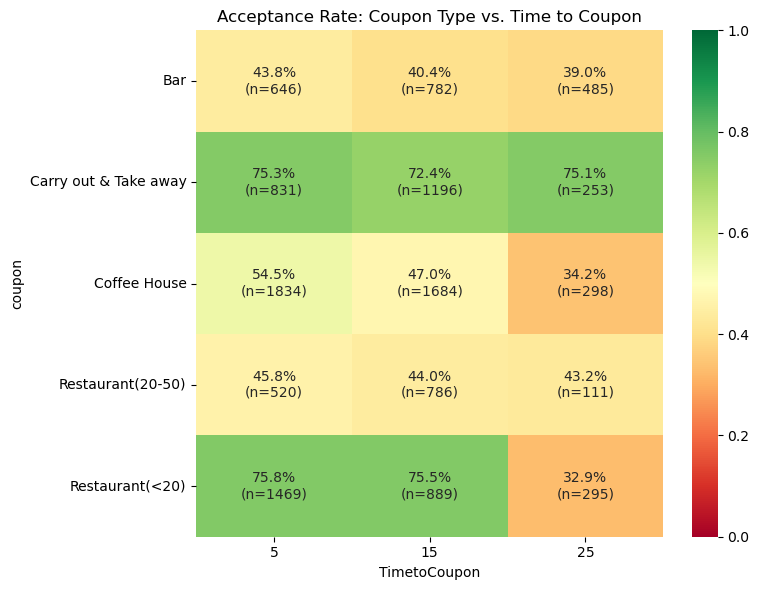

In [188]:
# Acceptance rate pivot
pivot_rate = df.pivot_table(
    values='accepted_coupon',
    index='coupon',
    columns='TimetoCoupon',
    aggfunc='mean'
)

# Count pivot
pivot_count = df.pivot_table(
    values='accepted_coupon',
    index='coupon',
    columns='TimetoCoupon',
    aggfunc='size'
)

# Create combined annotation labels
annot_labels = pd.DataFrame('', index=pivot_rate.index, columns=pivot_rate.columns)
for i in range(len(pivot_rate)):
    for j in range(len(pivot_rate.columns)):
        rate = pivot_rate.iloc[i, j]
        count = int(pivot_count.iloc[i, j])
        annot_labels.iloc[i, j] = f'{rate:.1%}\n(n={count})'

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_rate, annot=annot_labels, fmt='', cmap='RdYlGn', vmin=0, vmax=1)
plt.title('Acceptance Rate: Coupon Type vs. Time to Coupon')
plt.tight_layout()
plt.show()

Based on this analysis we would recommend to the stakeholders to create the next campaigns in the Carry out and Restaurant<20 categories, but in the last category, only to send coupons if Driver is 15 minutes or less away.